<a href="https://colab.research.google.com/github/Rajeshsivamoorthy/ML_INTERPRETATION/blob/main/RADAR_CHART%26CONFUSION_MATRIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

HTML("<div style='column-count: 2;'>{}</div>".format(code))

In [32]:
!apt-get install -y fonts-mscorefonts-installer

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package fonts-mscorefonts-installer


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files # Added for upload functionality
import os # Added for common pairing with files.upload, though not directly used in this snippet

print("You can upload a new CSV for the radar plot now, or press Cancel to use the previously loaded data.")
uploaded_files = files.upload()

if uploaded_files:
    # Assuming only one file is uploaded at a time for this context
    uploaded_filename = list(uploaded_files.keys())[0]
    try:
        radar_df = pd.read_csv(uploaded_filename)
        print(f"Successfully loaded '{uploaded_filename}' into radar_df.")
    except Exception as e:
        print(f"Error reading uploaded file '{uploaded_filename}': {e}. Falling back to previously loaded 'df'.")
        radar_df = df
else:
    print("No new CSV uploaded. Using previously loaded 'df' for radar_df.")
    radar_df = df

print("First 5 rows of radar_df:")
display(radar_df.head())

You can upload a new CSV for the radar plot now, or press Cancel to use the previously loaded data.


Saving RADAR.csv to RADAR (4).csv
Successfully loaded 'RADAR (4).csv' into radar_df.
First 5 rows of radar_df:


,Model,Precision,Recall,Specificty,F1-Score
0,Random Tree,0.917577,0.921865,0.654903,0.919057
1,Random Forest,0.929404,0.933027,0.688085,0.930345
2,Decision Stump,0.808363,0.873933,0.133593,0.818828
3,OneR,0.879742,0.892318,0.298680,0.863597
4,Rep Tree,0.902827,0.910703,0.567566,0.904760



Enter output file type (png, tif, pdf): tif
Enter DPI value (300 / 600 / 900): 300


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

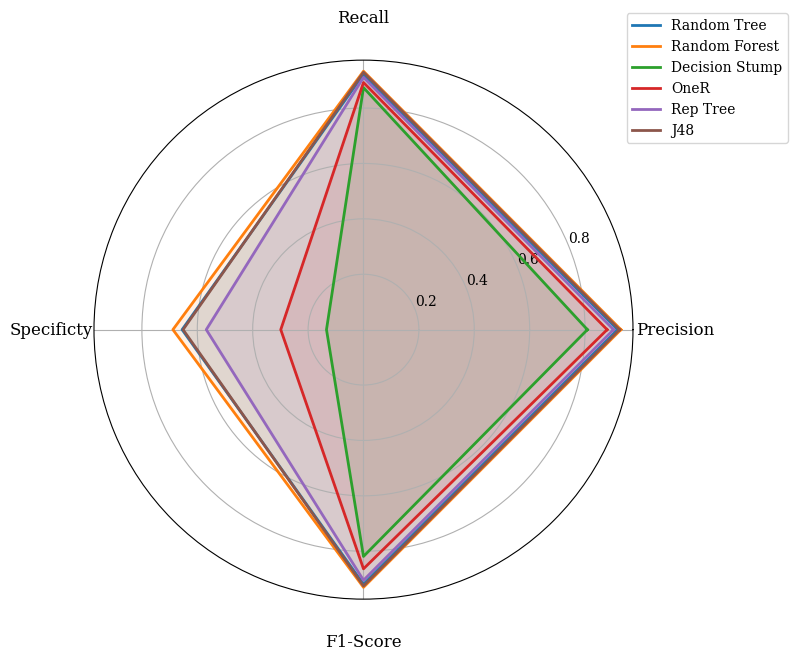

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'DejaVu Serif'

categories = list(radar_df.columns[1:])  # Exclude Model column
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

# Plot each model
for i in range(len(radar_df)):

    values = radar_df.iloc[i, 1:].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=radar_df.iloc[i, 0])
    ax.fill(angles, values, alpha=0.1)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontname="DejaVu Serif")

# Move labels outside
ax.tick_params(axis='x', pad=20)

# Y-axis tick font
for label in ax.get_yticklabels():
    label.set_fontname("DejaVu Serif")

# Legend with Times New Roman
legend = plt.legend(loc='upper right', bbox_to_anchor=(1.3,1.1))
for text in legend.get_texts():
    text.set_fontname("DejaVu Serif")

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (png, tif, pdf): ").strip().lower()
dpi_value = int(input("Enter DPI value (300 / 600 / 900): ").strip())

# === Save figure ===
output_filename = f"HEATMAP.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')

files.download(output_filename)

plt.show()

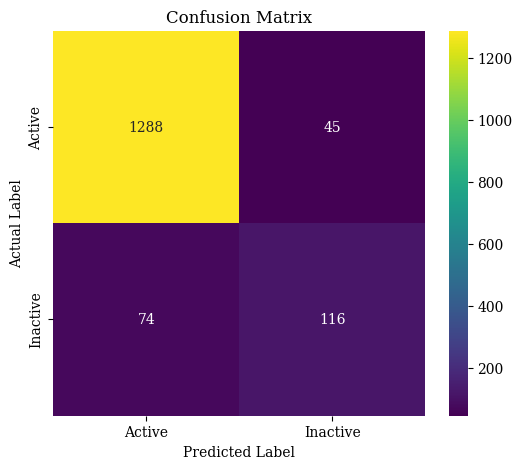

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example values (replace with yours)
TP = 1288
TN = 116
FP = 74
FN = 45

conf_matrix = np.array([[TP, FN],
                        [FP, TN]])

plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="viridis", # Changed colormap from "Blues" to "viridis"
    xticklabels=["Active", "Inactive"],
    yticklabels=["Active", "Inactive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()